## Customer Purchase Prediction

## Problem Statement

The rapid growth of e-commerce has increased the need for businesses to understand customer purchasing behavior. However, not all website visitors convert into buyers, making it challenging to identify which users are likely to complete a purchase.
This project aims to develop a machine learning model that predicts whether a customer will make a purchase based on their browsing behavior and session data. By analyzing user interactions such as page visits, bounce rates, and engagement metrics, the model seeks to classify customers into potential buyers and non-buyers.


## Business Importance

Accurately predicting customer purchase behavior provides significant value to e-commerce businesses:
- Targeted Marketing: Enables companies to focus marketing efforts on high-intent customers, improving campaign effectiveness. 
- Revenue Optimization: Increases conversion rates by identifying and nurturing potential buyers. 
- Cost Efficiency: Reduces wasted advertising spend on low-probability customers. 
- Personalization: Supports tailored product recommendations and user experiences. 
- Strategic Decision-Making: Helps businesses understand key behavioral drivers influencing purchases. 



## Import Libraries

In [2]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import xgboost as xgb

# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [3]:
df = pd.read_csv(r"C:\Users\USER\Downloads\archive (21)\online_shoppers_intention.csv")


In [4]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## Data Overview

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [6]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [7]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

## Exploratory Data Analysis

#### Target Distribution

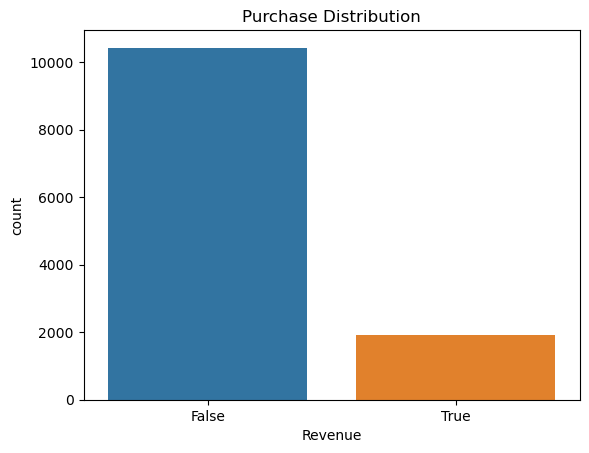

In [8]:
sns.countplot(x='Revenue', data=df)
plt.title("Purchase Distribution")
plt.show()

In [9]:
df['Revenue'].value_counts(normalize=True)

False    0.845255
True     0.154745
Name: Revenue, dtype: float64

##### Insight: The dataset is imbalanced, with a significantly lower proportion of customers making purchases compared to those who do not.

#### Correlation Heatmap

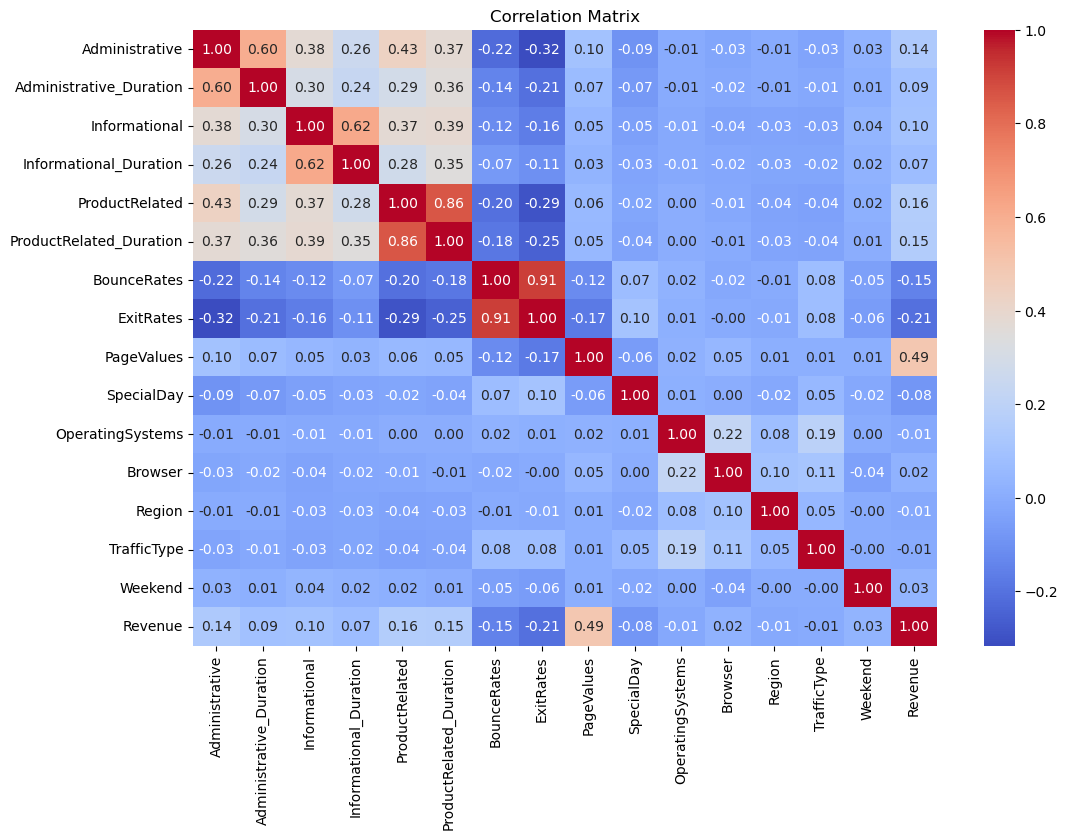

In [10]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

#### Behavioral Insights

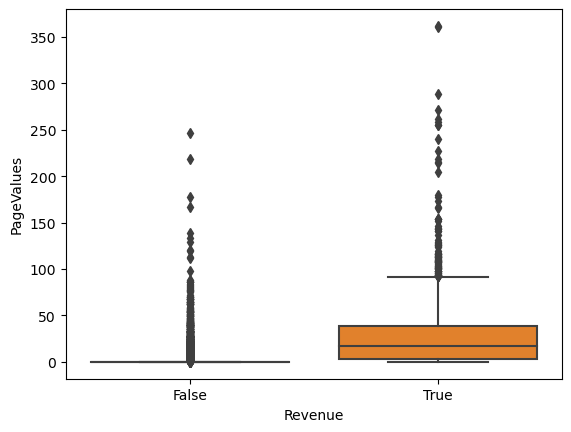

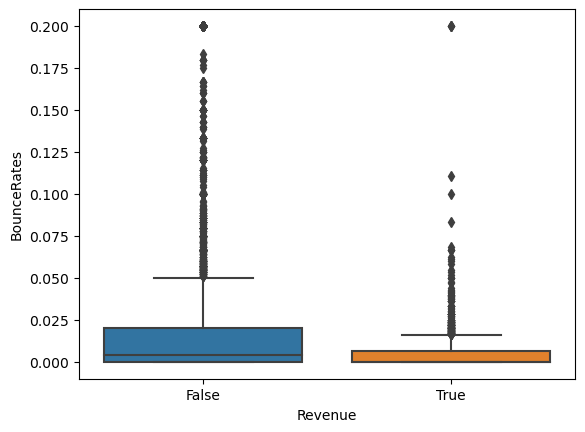

In [11]:
sns.boxplot(x='Revenue', y='PageValues', data=df)
plt.show()

sns.boxplot(x='Revenue', y='BounceRates', data=df)
plt.show()

## Data Preprocessing

#### Encode Categorical Variables

In [12]:
le = LabelEncoder()

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

#### Convert Target Variable

In [13]:
df['Revenue'] = df['Revenue'].astype(int)

#### Feature & Target Split

In [14]:
X = df.drop('Revenue', axis=1)
y = df['Revenue']

#### Train-Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#### Feature Scaling

In [16]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Training

In [17]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

## Model Evaluation Function

In [18]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title("Confusion Matrix")
    plt.show()

## Train & Evaluate All Models


Logistic Regression
Accuracy: 0.8832116788321168
Precision: 0.7640449438202247
Recall: 0.35602094240837695
F1 Score: 0.48571428571428565

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.98      0.93      2084
           1       0.76      0.36      0.49       382

    accuracy                           0.88      2466
   macro avg       0.83      0.67      0.71      2466
weighted avg       0.87      0.88      0.86      2466



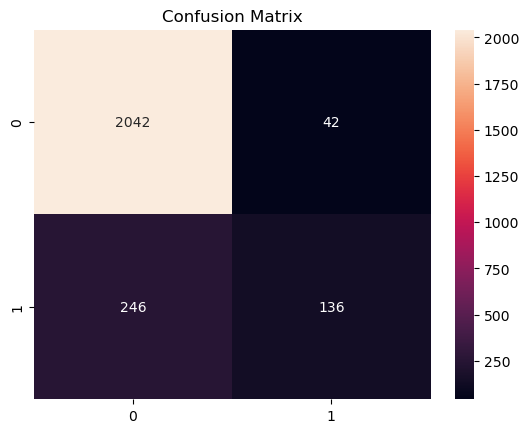


Decision Tree
Accuracy: 0.8576642335766423
Precision: 0.5392405063291139
Recall: 0.5575916230366492
F1 Score: 0.5482625482625483

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.91      0.92      2084
           1       0.54      0.56      0.55       382

    accuracy                           0.86      2466
   macro avg       0.73      0.74      0.73      2466
weighted avg       0.86      0.86      0.86      2466



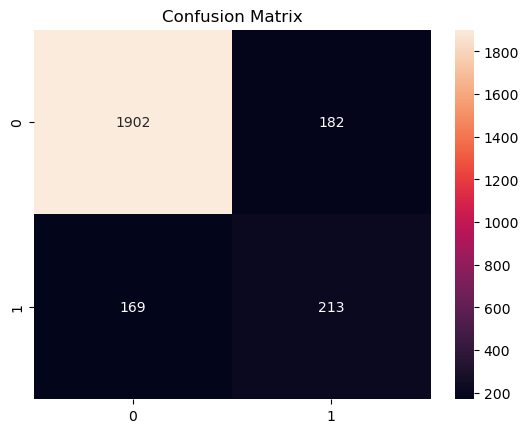


Random Forest
Accuracy: 0.902676399026764
Precision: 0.7482517482517482
Recall: 0.5602094240837696
F1 Score: 0.6407185628742516

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.94      2084
           1       0.75      0.56      0.64       382

    accuracy                           0.90      2466
   macro avg       0.84      0.76      0.79      2466
weighted avg       0.90      0.90      0.90      2466



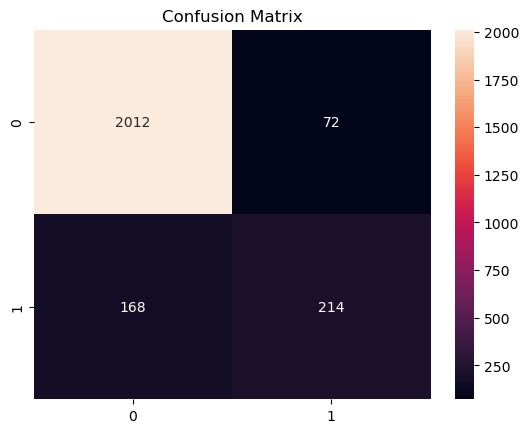


Gradient Boosting
Accuracy: 0.8986212489862125
Precision: 0.7156862745098039
Recall: 0.5732984293193717
F1 Score: 0.6366279069767442

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.96      0.94      2084
           1       0.72      0.57      0.64       382

    accuracy                           0.90      2466
   macro avg       0.82      0.77      0.79      2466
weighted avg       0.89      0.90      0.89      2466



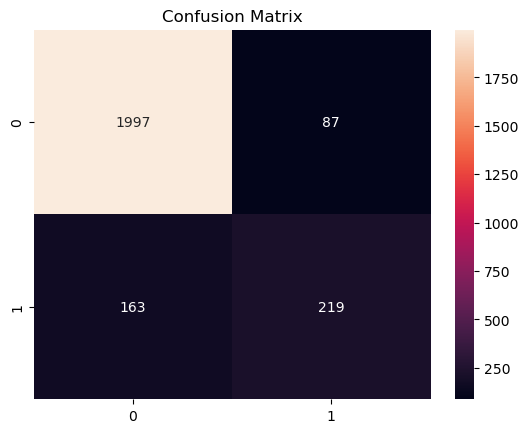


XGBoost
Accuracy: 0.889294403892944
Precision: 0.6697819314641744
Recall: 0.56282722513089
F1 Score: 0.6116642958748221

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.95      0.94      2084
           1       0.67      0.56      0.61       382

    accuracy                           0.89      2466
   macro avg       0.80      0.76      0.77      2466
weighted avg       0.88      0.89      0.89      2466



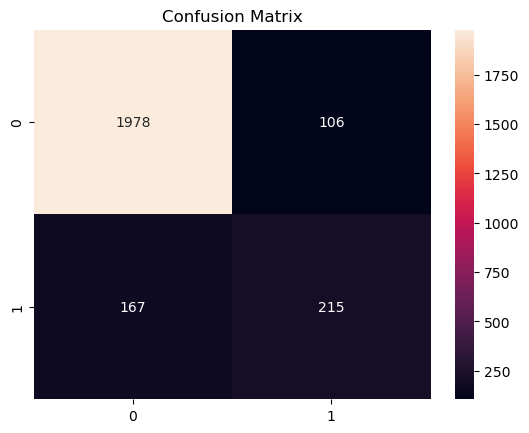

In [19]:
results = {}

for name, model in models.items():
    print(f"\n{name}")
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    f1 = f1_score(y_test, y_pred)
    results[name] = f1
    
    evaluate_model(model, X_test, y_test)

## Model Comparison

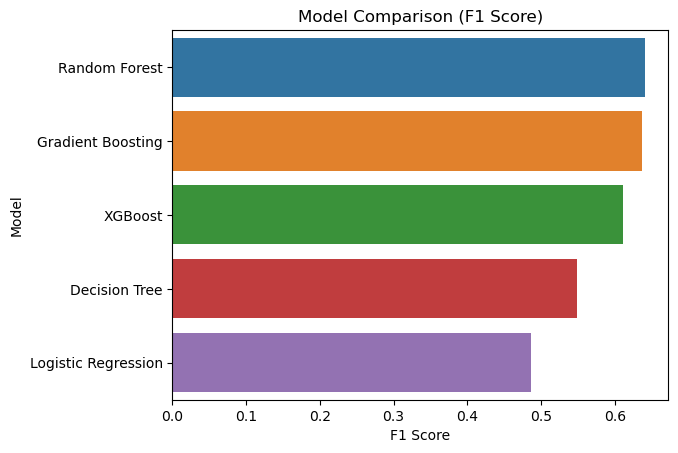

,Model,F1 Score
2,Random Forest,0.640719
3,Gradient Boosting,0.636628
4,XGBoost,0.611664
1,Decision Tree,0.548263
0,Logistic Regression,0.485714


In [20]:
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'F1 Score'])
results_df = results_df.sort_values(by='F1 Score', ascending=False)

sns.barplot(x='F1 Score', y='Model', data=results_df)
plt.title("Model Comparison (F1 Score)")
plt.show()

results_df

## Feature Importance (Best Model Example: Random Forest)

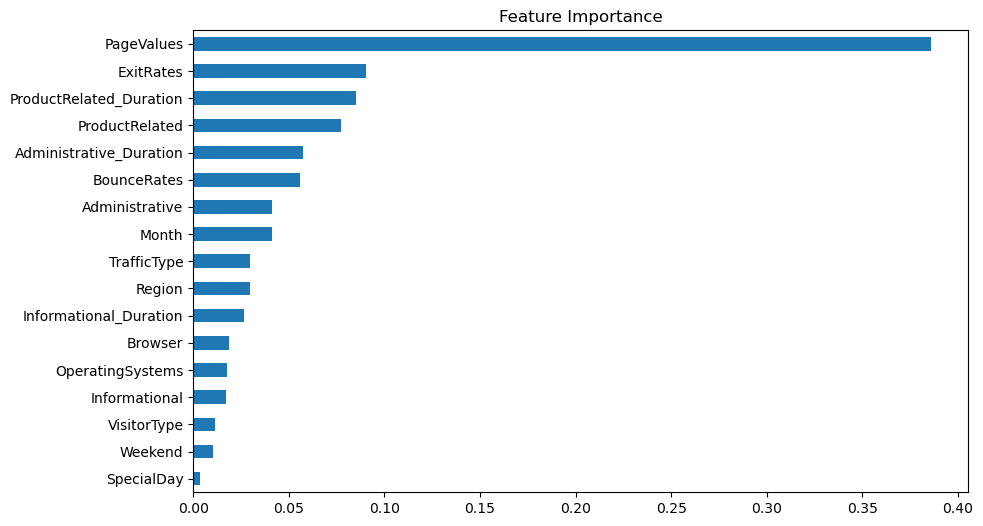

In [21]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

importances = rf.feature_importances_

feat_importance = pd.Series(importances, index=X.columns)
feat_importance.sort_values().plot(kind='barh', figsize=(10,6))
plt.title("Feature Importance")
plt.show()

## Business Recommendations

Based on the analysis and model insights, the following recommendations are proposed:
1. Focus on High-Intent Customers
- Prioritize users with high PageValues and strong engagement. 
- Deploy targeted promotions (discounts, reminders) to convert them. 

2. Reduce Bounce Rates
- Optimize landing pages for better user experience. 
- Improve page load speed and content relevance to retain visitors. 

3. Leverage Returning Visitors
- Returning users show higher purchase likelihood. 
- Implement loyalty programs and personalized email campaigns.

4. Implement Real-Time Prediction Systems (Integrate the model into the website to) 
- Identify high-probability buyers in real time 
- Trigger personalized offers instantly 

5. Data-Driven Marketing Strategy  (Use insights from the model to) 
- Segment customers 
- Optimize ad targeting 
- Improve ROI on campaigns 


This project demonstrates how machine learning can bridge the gap between customer behavior and business strategy, enabling smarter and more efficient decision-making.


In [22]:
# Add predictions
df['Predicted_Revenue'] = model.predict(X)

# Add probability 
df['Purchase_Probability'] = model.predict_proba(X)[:, 1]

# Save dataset
df.to_csv("final_with_predictions.csv", index=False)

print("File saved successfully!")

File saved successfully!
